Inspired by disussion around the assumptions about flux and flux density in JWST imaging vs spectroscopy

In [1]:
from pathlib import Path

import numpy as np

from matplotlib import pyplot as plt


from astropy import units as u
from astropy import constants as cnst
from astropy import modeling
from astropy.table import QTable
from astropy import cosmology
from astropy.visualization import quantity_support
quantity_support()

from astroquery.svo_fps import SvoFps

from jwst import datamodels

In [2]:
jwfilts = SvoFps.get_filter_list('JWST')
jwfilts

FilterProfileService,filterID,WavelengthUnit,WavelengthUCD,PhotSystem,DetectorType,Band,Instrument,Facility,ProfileReference,CalibrationReference,Description,Comments,WavelengthRef,WavelengthMean,WavelengthEff,WavelengthMin,WavelengthMax,WidthEff,WavelengthCen,WavelengthPivot,WavelengthPeak,WavelengthPhot,FWHM,Fsun,PhotCalID,MagSys,ZeroPoint,ZeroPointUnit,Mag0,ZeroPointType,AsinhSoft,TrasmissionCurve
,,,,,,,,,,,,,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,erg / (A s cm2),,,Jy,,,,,
object,object,object,object,object,object,object,object,object,object,object,object,object,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,object,object,float64,object,float64,object,float64,object
ivo://svo/fps,JWST/NIRCam.F070W,Angstrom,em.wl,NIRCam,1,,NIRCam,JWST,https://jwst-docs.stsci.edu/display/JTI/NIRCam+Filters,,NIRCam F070W filter,"includes NIRCam optics, DBS, QE and JWST Optical Telescope Element",7039.1194650654,7088.3009369996,6988.4272768359,6048.1970523246,7927.0738659178,1212.8399166581,7099.1873443748,7039.1194650654,7691.5,7022.060805287,1430.8105961315,140.01772043307,JWST/NIRCam.F070W/Vega,Vega,2768.4045696982,Jy,0.0,Pogson,0.0,http://svo2.cab.inta-csic.es//theory/fps/fps.php?ID=JWST/NIRCam.F070W
ivo://svo/fps,JWST/NIRCam2025.F070W,Angstrom,em.wl,NIRCam2025,1,F070W,NIRCam,JWST,https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-instrumentation/nircam-filters#gsc.tab=0,,NIRCam F070W filter . Updated Feb 2025,"includes contributions from the JWST Optical Telescope Element (OTE), NIRCam optical train, dichroics, filters, and detector quantum efficiency (QE).",7047.0952782899,7096.4471977696,6996.0621457337,6031.564443372,8002.7266224207,1176.4945807066,7119.8451290999,7047.0952782899,7691.500244140626,7029.9042919888,1389.660407148,139.76039455597,JWST/NIRCam2025.F070W/Vega,Vega,2765.4619957744,Jy,0.0,Pogson,0.0,http://svo2.cab.inta-csic.es//theory/fps/fps.php?ID=JWST/NIRCam2025.F070W
ivo://svo/fps,JWST/NIRISS.F090W,Angstrom,em.wl,NIRISS,1,,NIRISS,JWST,http://jwst.astro.umontreal.ca/?page_id=116,,NIRISS F090W filter,,9003.8974145327,9066.74387194,8966.950481369,7891.4713377308,10241.102511507,1769.2561253306,9008.6175845746,9003.8974145327,9890.0,9008.8529709138,2082.7777922023,89.607260396174,JWST/NIRISS.F090W/Vega,Vega,2245.9690953816,Jy,0.0,Pogson,0.0,http://svo2.cab.inta-csic.es//theory/fps/fps.php?ID=JWST/NIRISS.F090W
ivo://svo/fps,JWST/NIRCam.F090W,Angstrom,em.wl,NIRCam,1,,NIRCam,JWST,https://jwst-docs.stsci.edu/display/JTI/NIRCam+Filters,,NIRCam F090W filter,"includes NIRCam optics, DBS, QE and JWST Optical Telescope Element",9021.5288283376,9083.3952700859,8984.9812166695,7881.875216583,10243.081731613,1772.7418859059,9007.2449821231,9021.5288283376,9905.5,9026.3413455784,2088.0551132236,89.25825936013,JWST/NIRCam.F090W/Vega,Vega,2244.9507457345,Jy,0.0,Pogson,0.0,http://svo2.cab.inta-csic.es//theory/fps/fps.php?ID=JWST/NIRCam.F090W
ivo://svo/fps,JWST/NIRCam2025.F090W,Angstrom,em.wl,NIRCam2025,1,F090W,NIRCam,JWST,https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-instrumentation/nircam-filters#gsc.tab=0,,NIRCam F090W filter . Updated Feb 2025,"includes contributions from the JWST Optical Telescope Element (OTE), NIRCam optical train, dichroics, filters, and detector quantum efficiency (QE).",9023.9972876396,9085.7623664097,8987.4950763565,7855.0097724131,10314.281828892,1768.8899619018,9008.1048972632,9023.9972876396,9905.499877929688,9028.7927987061,2087.1628077432,89.209033824668,JWST/NIRCam2025.F090W/Vega,Vega,2244.6272448376,Jy,0.0,Pogson,0.0,http://svo2.cab.inta-csic.es//theory/fps/fps.php?ID=JWST/NIRCam2025.F090W
ivo://svo/fps,JWST/NIRISS.F115W,Angstrom,em.wl,NIRISS,1,,NIRISS,JWST,http://jwst.astro.umontreal.ca/?page_id=116,,NIRISS F115W filter,,11501.017719302,11584.04916236,11389.982969661,9974.3382764767,13062.607949993,2193.9517443543,11489.395601534,11501.017719302,12690.0,11445.732592155,2679.6

In [3]:
jwfilts[jwfilts['Instrument'] == 'NIRCam']

FilterProfileService,filterID,WavelengthUnit,WavelengthUCD,PhotSystem,DetectorType,Band,Instrument,Facility,ProfileReference,CalibrationReference,Description,Comments,WavelengthRef,WavelengthMean,WavelengthEff,WavelengthMin,WavelengthMax,WidthEff,WavelengthCen,WavelengthPivot,WavelengthPeak,WavelengthPhot,FWHM,Fsun,PhotCalID,MagSys,ZeroPoint,ZeroPointUnit,Mag0,ZeroPointType,AsinhSoft,TrasmissionCurve
,,,,,,,,,,,,,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,erg / (A s cm2),,,Jy,,,,,
object,object,object,object,object,object,object,object,object,object,object,object,object,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,object,object,float64,object,float64,object,float64,object
ivo://svo/fps,JWST/NIRCam.F070W,Angstrom,em.wl,NIRCam,1,,NIRCam,JWST,https://jwst-docs.stsci.edu/display/JTI/NIRCam+Filters,,NIRCam F070W filter,"includes NIRCam optics, DBS, QE and JWST Optical Telescope Element",7039.1194650654,7088.3009369996,6988.4272768359,6048.1970523246,7927.0738659178,1212.8399166581,7099.1873443748,7039.1194650654,7691.5,7022.060805287,1430.8105961315,140.01772043307,JWST/NIRCam.F070W/Vega,Vega,2768.4045696982,Jy,0.0,Pogson,0.0,http://svo2.cab.inta-csic.es//theory/fps/fps.php?ID=JWST/NIRCam.F070W
ivo://svo/fps,JWST/NIRCam2025.F070W,Angstrom,em.wl,NIRCam2025,1,F070W,NIRCam,JWST,https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-instrumentation/nircam-filters#gsc.tab=0,,NIRCam F070W filter . Updated Feb 2025,"includes contributions from the JWST Optical Telescope Element (OTE), NIRCam optical train, dichroics, filters, and detector quantum efficiency (QE).",7047.0952782899,7096.4471977696,6996.0621457337,6031.564443372,8002.7266224207,1176.4945807066,7119.8451290999,7047.0952782899,7691.500244140626,7029.9042919888,1389.660407148,139.76039455597,JWST/NIRCam2025.F070W/Vega,Vega,2765.4619957744,Jy,0.0,Pogson,0.0,http://svo2.cab.inta-csic.es//theory/fps/fps.php?ID=JWST/NIRCam2025.F070W
ivo://svo/fps,JWST/NIRCam.F090W,Angstrom,em.wl,NIRCam,1,,NIRCam,JWST,https://jwst-docs.stsci.edu/display/JTI/NIRCam+Filters,,NIRCam F090W filter,"includes NIRCam optics, DBS, QE and JWST Optical Telescope Element",9021.5288283376,9083.3952700859,8984.9812166695,7881.875216583,10243.081731613,1772.7418859059,9007.2449821231,9021.5288283376,9905.5,9026.3413455784,2088.0551132236,89.25825936013,JWST/NIRCam.F090W/Vega,Vega,2244.9507457345,Jy,0.0,Pogson,0.0,http://svo2.cab.inta-csic.es//theory/fps/fps.php?ID=JWST/NIRCam.F090W
ivo://svo/fps,JWST/NIRCam2025.F090W,Angstrom,em.wl,NIRCam2025,1,F090W,NIRCam,JWST,https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-instrumentation/nircam-filters#gsc.tab=0,,NIRCam F090W filter . Updated Feb 2025,"includes contributions from the JWST Optical Telescope Element (OTE), NIRCam optical train, dichroics, filters, and detector quantum efficiency (QE).",9023.9972876396,9085.7623664097,8987.4950763565,7855.0097724131,10314.281828892,1768.8899619018,9008.1048972632,9023.9972876396,9905.499877929688,9028.7927987061,2087.1628077432,89.209033824668,JWST/NIRCam2025.F090W/Vega,Vega,2244.6272448376,Jy,0.0,Pogson,0.0,http://svo2.cab.inta-csic.es//theory/fps/fps.php?ID=JWST/NIRCam2025.F090W
ivo://svo/fps,JWST/NIRCam2025.F115W,Angstrom,em.wl,NIRCam2025,1,F115W,NIRCam,JWST,https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-instrumentation/nircam-filters#gsc.tab=0,,NIRCam F115W filter . Updated Feb 2025,"includes contributions from the JWST Optical Telescope Element (OTE), NIRCam optical train, dichroics, filters, and detector quantum efficiency (QE)",11540.775048192,11622.229778454,11431.589321774,9972.0417179249,13190.793271674,2052.8364431293,11493.291385525,11540.775048192,12691.99951171875,11486.924641208,2646.3968763149,53.05166879958,JWST/NIRCam2025.F115W/Vega,Vega,1746.5216552138,Jy,0.0,Pogson,0.0,http://svo2.cab.inta-csic.es//theory/fps/fps.php?ID=JWST/NIRCam2025.F115W
ivo://svo/fps,JWST/NIRCam.F115W

In [4]:
f187n = QTable(SvoFps.get_transmission_data('JWST/NIRCam2025.F187N'))

In [5]:
meta = SvoFps.get_filter_metadata('JWST/NIRCam2025.F187N')
meta

{'FilterProfileService': 'ivo://svo/fps',
 'filterID': 'JWST/NIRCam2025.F187N',
 'WavelengthUnit': 'Angstrom',
 'WavelengthUCD': 'em.wl',
 'Description': 'NIRCam  F187N filter . Updated Feb 2025',
 'PhotSystem': 'NIRCam2025',
 'DetectorType': '1',
 'Band': 'F187N',
 'Instrument': 'NIRCam',
 'Facility': 'JWST',
 'ProfileReference': 'https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-instrumentation/nircam-filters#gsc.tab=0',
 'Comments': 'includes contributions from the JWST Optical Telescope Element (OTE), NIRCam optical train, dichroics, filters, and detector quantum efficiency (QE).',
 'components': 'Filter + CCD + Instrument + Other optical components',
 'WavelengthRef': <Quantity 18740.52700123 Angstrom>,
 'WavelengthMean': <Quantity 18741.18588282 Angstrom>,
 'WavelengthEff': <Quantity 18738.83129775 Angstrom>,
 'WavelengthMin': <Quantity 18395.66813112 Angstrom>,
 'WavelengthMax': <Quantity 19087.48480477 Angstrom>,
 'WidthEff': <Quantity 236.39754494 Angstrom>,
 'Wavel

In [6]:
paa = 1.87561*u.um

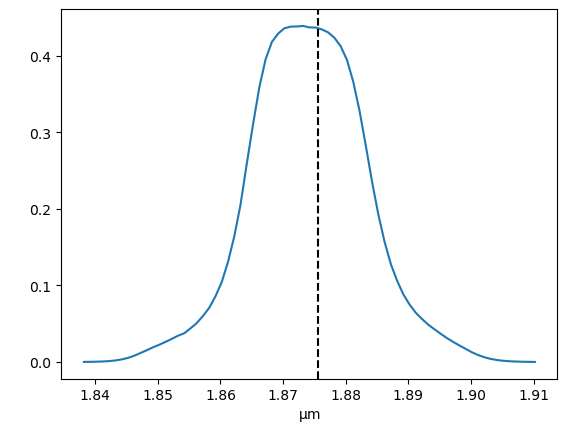

In [7]:
plt.plot(f187n['Wavelength'].to(paa.unit), f187n['Transmission'])
plt.axvline(paa, color='k', ls='--')

In [8]:
vwidth = 100*u.km/u.s
lambwidth = (vwidth/cnst.c * paa).to(paa.unit)
lambwidth

<Quantity 0.00062564 um>

<Quantity 23.71997321 Mpc>

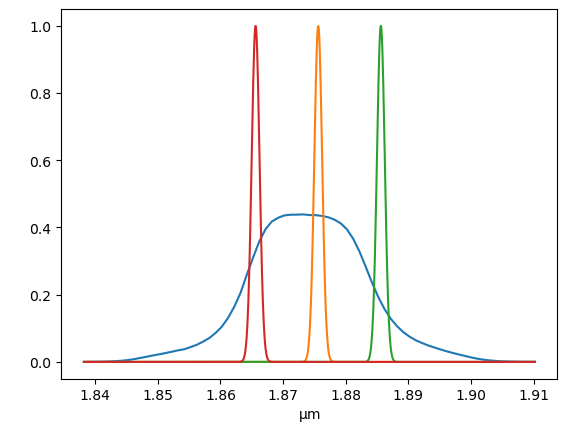

In [9]:
line = modeling.models.Gaussian1D(amplitude=1*u.erg/u.s * u.cm**-2 / u.micron, mean=paa, stddev=lambwidth)
lineoff1 = modeling.models.Gaussian1D(amplitude=1*u.erg/u.s * u.cm**-2 / u.micron, mean=paa+.01*u.micron, stddev=lambwidth)
lineoff2 = modeling.models.Gaussian1D(amplitude=1*u.erg/u.s * u.cm**-2 / u.micron, mean=paa-.01*u.micron, stddev=lambwidth)

x = np.linspace(f187n['Wavelength'][0], f187n['Wavelength'][-1], 1024)
dx = np.diff(x).mean()

plt.plot(f187n['Wavelength'].to(paa.unit), f187n['Transmission'])
plt.plot(x, line(x).value)
plt.plot(x, lineoff1(x).value)
plt.plot(x, lineoff2(x).value)

cosmology.Planck18.luminosity_distance(.01*u.um / paa)

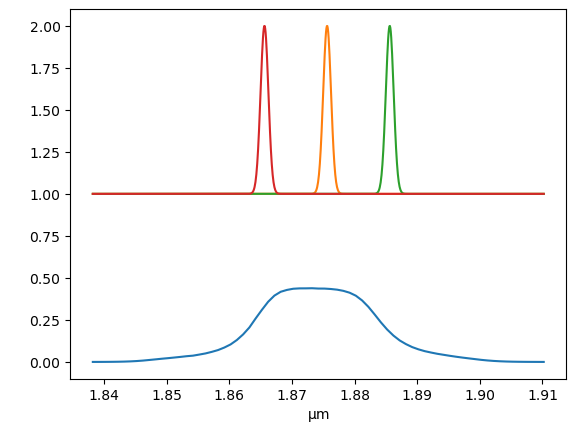

In [10]:
linecont = line + modeling.models.Const1D(line.amplitude)
lineoff1cont = lineoff1 + modeling.models.Const1D(line.amplitude)
lineoff2cont = lineoff2 + modeling.models.Const1D(line.amplitude)

x = np.linspace(f187n['Wavelength'][0], f187n['Wavelength'][-1], 1024)
dx = np.diff(x).mean()

plt.plot(f187n['Wavelength'].to(paa.unit), f187n['Transmission'])
plt.plot(x, linecont(x).value)
plt.plot(x, lineoff1cont(x).value)
plt.plot(x, lineoff2cont(x).value)

First lets compute the pivot wavelength, which is source-independent:

In [11]:
np.all(np.diff(f187n['Wavelength']) == np.diff(f187n['Wavelength'])[0])

MaskedNDArray(True)

In [12]:
dlambdatrans = np.diff(f187n['Wavelength']).mean()

numer = np.sum(f187n['Transmission'] * f187n['Wavelength'] * dlambdatrans)
denom = np.sum(f187n['Transmission'] / f187n['Wavelength'] * dlambdatrans)

pivot = ((numer/denom)**0.5).to(paa.unit)
pivot

<MaskedQuantity 1.87405268 um>

In [13]:
meta['WavelengthPivot'].to(paa.unit)

<Quantity 1.8740527 um>

Good, that checks out.  Now effective wavelength for the various line scenarios

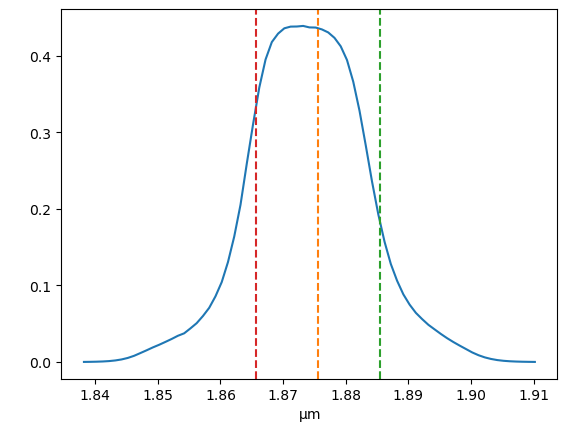

In [14]:
x = np.linspace(f187n['Wavelength'][0], f187n['Wavelength'][-1], 1024)
dx = np.diff(x).mean()
xtrans = np.interp(x, f187n['Wavelength'], f187n['Transmission'])

leff_line = np.sum(x * line(x) * xtrans * x * dx) / np.sum(line(x) * xtrans * x * dx)
leff_lineoff1 = np.sum(x * lineoff1(x) * xtrans * x * dx) / np.sum(lineoff1(x) * xtrans * x * dx)
leff_lineoff2 = np.sum(x * lineoff2(x) * xtrans * x * dx) / np.sum(lineoff2(x) * xtrans * x * dx)

plt.plot(f187n['Wavelength'].to(paa.unit), f187n['Transmission'])
plt.axvline(leff_line, color='C1', ls='--')
plt.axvline(leff_lineoff1, color='C2', ls='--')
plt.axvline(leff_lineoff2, color='C3', ls='--')

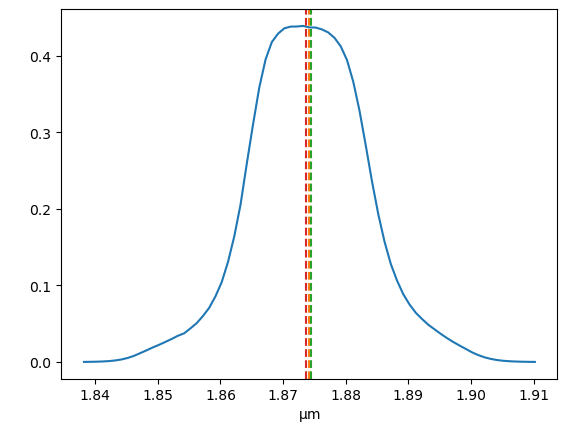

In [15]:
x = np.linspace(f187n['Wavelength'][0], f187n['Wavelength'][-1], 1024)
dx = np.diff(x).mean()
xtrans = np.interp(x, f187n['Wavelength'], f187n['Transmission'])

leff_linecont = np.sum(x * linecont(x) * xtrans * x * dx) / np.sum(linecont(x) * xtrans * x * dx)
leff_lineoff1cont = np.sum(x * lineoff1cont(x) * xtrans * x * dx) / np.sum(lineoff1cont(x) * xtrans * x * dx)
leff_lineoff2cont = np.sum(x * lineoff2cont(x) * xtrans * x * dx) / np.sum(lineoff2cont(x) * xtrans * x * dx)

plt.plot(f187n['Wavelength'].to(paa.unit), f187n['Transmission'])
plt.axvline(leff_linecont, color='C1', ls='--')
plt.axvline(leff_lineoff1cont, color='C2', ls='--')
plt.axvline(leff_lineoff2cont, color='C3', ls='--')

Unsurprisingly, the effective wavlength is concentrated where the flux is, so for a very strong line its shifted while a moderate one its basically the same as for a flat spectrum.

Now lets calculate the average flux density in each case (a la Gordon et al. 2022 eqn 5).

In [16]:
x = np.linspace(f187n['Wavelength'][0], f187n['Wavelength'][-1], 1024)
dx = np.diff(x).mean()
xtrans = np.interp(x, f187n['Wavelength'], f187n['Transmission'])

def avgfluxden(fx, xtrans, dx):
    numer = np.sum(fx * xtrans * x * dx)
    denom = np.sum(xtrans * x * dx)
    return numer/denom

In [17]:
line_fluxden = avgfluxden(line(x), xtrans, dx)
line_fluxden

<MaskedQuantity 0.06590585 erg / (micron s cm2)>

In [18]:
lineoff1_fluxden = avgfluxden(lineoff1(x), xtrans, dx)
lineoff1_fluxden

<MaskedQuantity 0.02728989 erg / (micron s cm2)>

In [19]:
lineoff2_fluxden = avgfluxden(lineoff2(x), xtrans, dx)
lineoff2_fluxden

<MaskedQuantity 0.0495447 erg / (micron s cm2)>

In [20]:
linecont_fluxden = avgfluxden(linecont(x), xtrans, dx)
linecont_fluxden

<MaskedQuantity 1.06590585 erg / (micron s cm2)>

In [21]:
lineoff1cont_fluxden = avgfluxden(lineoff1cont(x), xtrans, dx)
lineoff1cont_fluxden

<MaskedQuantity 1.02728989 erg / (micron s cm2)>

In [22]:
lineoff2cont_fluxden = avgfluxden(lineoff2cont(x), xtrans, dx)
lineoff2cont_fluxden

<MaskedQuantity 1.0495447 erg / (micron s cm2)>

So it depends a lot on where the line is.  

But it is additive in the sense that the line flux adds to a constant spectrum the normal linear way (which of course has to be true since flux addition is linear in Eq 5)

Now consider more typical measures of  actual flux:

$\int F(\lambda) d \lambda$

In [23]:
line_flux = np.sum(line(x)*dx).to(u.erg/u.s * u.cm**-2)
line_flux

<MaskedQuantity 0.00156824 erg / (s cm2)>

In [24]:
lineoff1_flux = np.sum(lineoff1(x)*dx).to(u.erg/u.s * u.cm**-2)
lineoff1_flux

<MaskedQuantity 0.00156824 erg / (s cm2)>

In [25]:
lineoff2_flux = np.sum(lineoff2(x)*dx).to(u.erg/u.s * u.cm**-2)
lineoff2_flux

<MaskedQuantity 0.00156824 erg / (s cm2)>

In [26]:
linecont_flux = np.sum(linecont(x)*dx).to(u.erg/u.s * u.cm**-2)
linecont_flux

<MaskedQuantity 0.07363862 erg / (s cm2)>

In [27]:
lineoff1cont_flux = np.sum(lineoff1cont(x)*dx).to(u.erg/u.s * u.cm**-2)
lineoff1cont_flux

<MaskedQuantity 0.07363862 erg / (s cm2)>

In [28]:
lineoff2cont_flux = np.sum(lineoff2cont(x)*dx).to(u.erg/u.s * u.cm**-2)
lineoff2cont_flux

<MaskedQuantity 0.07363862 erg / (s cm2)>

Of course these don't care about the bandpass at all, so they are consistent in the various cases.

Try working out what the multiplicative wavelength would be for whatever flux correction factor is needed:

In [29]:
line_flux / line_fluxden

<MaskedQuantity 0.02379511 micron>

In [30]:
lineoff1_flux / lineoff1_fluxden

<MaskedQuantity 0.05746586 micron>

In [31]:
lineoff2_flux / lineoff2_fluxden

<MaskedQuantity 0.03165298 micron>

In [32]:
linecont_flux / linecont_fluxden

<MaskedQuantity 0.06908548 micron>

In [33]:
lineoff1cont_flux / lineoff1cont_fluxden

<MaskedQuantity 0.07168241 micron>

In [34]:
lineoff2cont_flux / lineoff2cont_fluxden

<MaskedQuantity 0.07016244 micron>

None of these have any obvious connection to the other  wavelength quantities defined above.  So lets try something a bit more principles: define a wavelength that is the conversion wavelength between flux and Gordon et al convention A flux density:

$\lambda_{\rm magic} \equiv \lambda_m = \int F(\lambda) d \lambda / (\frac{\int F(\lambda) R(\lambda) \lambda d\lambda}{\int R(\lambda) \lambda d\lambda})  $

This then has the property that $\int F(\lambda) d \lambda =  \lambda_m <F_\lambda>$

this requires a definition of F of course.  Lets consider two cases:

## Constant $F_\lambda$

In this case $F(\lambda) = F_0$.  Then:

$\lambda_m = \int(F_0 d\lambda) / (\frac{\int F_0 R(\lambda) \lambda d\lambda}{\int R(\lambda) \lambda d\lambda})$

$= F_0\int(d\lambda) / F_0 (\frac{\int R(\lambda) \lambda d\lambda}{\int R(\lambda) \lambda d\lambda})$

$=\int(d\lambda) = \lambda_2 - \lambda_1$

i.e., it's just the width of the total extent we're integrating over (which might be inifinity if we're thinking of a full spectrum, but no full spectrum is actually constant so it's ok that's non-physical)

# delta function $F_\lambda$


This is a degenerate version of a spectral line.  In this case $F(\lambda) = F_l \delta(\lambda - \lambda_l)$.  Then:


$\lambda_m = F_l\int(\delta(\lambda - \lambda_l) d\lambda) / (\frac{\int F_l \delta(\lambda - \lambda_l) R(\lambda) \lambda d\lambda}{\int R(\lambda) \lambda d\lambda})$

$= F_l / F_l (\frac{\int \delta(\lambda - \lambda_l) R(\lambda) \lambda d\lambda}{\int R(\lambda) \lambda d\lambda})$

$= 1 /  (\frac{ R(\lambda_l) \lambda_l}{\int R(\lambda) \lambda d\lambda})$
$= \frac{\int R(\lambda) \lambda d\lambda}{R(\lambda_l) \lambda_l}$

which, using the Bessel definition of mean photon wavelength:  $\lambda_0 = \frac{\int R(\lambda) \lambda d\lambda}{\int R(\lambda) d\lambda} $ (Bessell's S is our R here, I think?), this is equivalen to:

$= \lambda_0 \frac{\int R(\lambda) d\lambda}{R(\lambda_l) \lambda_l} = \frac{\lambda_0}{\lambda_l} / \frac{R(\lambda_l)}{\int R(\lambda) d\lambda}$

that is, it's the ratio of the mean to line wavelength scaled by the value of the *normalized* filter response at the line wavelength.

# Boxcar $F_\lambda$

In this case $F(\lambda) = F_b$ but only over $[\lambda_1, \lambda_2]$ and 0 elsewhere.  Then:

$\lambda_m = \int_{\lambda_1}^{\lambda_2}(F_b d\lambda) / (\frac{\int_{\lambda_1}^{\lambda_2} F_b R(\lambda) \lambda d\lambda}{\int_{0}^{\infty} R(\lambda) \lambda d\lambda})$

$= F_b\int_{\lambda_1}^{\lambda_2}(d\lambda) / F_b (\frac{\int_{\lambda_1}^{\lambda_2} R(\lambda) \lambda d\lambda}{\int_{0}^{\infty} R(\lambda) \lambda d\lambda})$

$= (\lambda_2 - \lambda_1) \frac{\int_{0}^{\infty} R(\lambda) \lambda d\lambda}{\int_{\lambda_1}^{\lambda_2} R(\lambda) \lambda d\lambda}$  

If R is normalized to 1 (i.e., is *not* a systerm throughput but rather a probability density), then this is 

$\frac{\lambda_2 - \lambda_1}{\int_{\lambda_1}^{\lambda_2} R(\lambda) \lambda d\lambda}$

Or thought of another way, $\lambda_m$ is $\lambda_2 - \lambda_1$ divided by the fraction of the passband that the boxcar covers.  If the boxcar is larger than the extent of the  passband this reduces to the constant $F_\lambda$ solution, which makes sense. Otherwise, the integral has to be evaluated.  

If the passband is *also* flat ($R_0$ over $[\lambda_{b,1}, \lambda_{b,2}]$), but bigger than the boxcar spectrum it reduces to the simpler:

$= (\lambda_2 - \lambda_1) \frac{\int_{\lambda_{b,2}}^{\lambda_{b,2}} R_0 \lambda d\lambda}{\int_{\lambda_1}^{\lambda_2} R_0\lambda d\lambda} = (\lambda_2 - \lambda_1) \frac{\lambda_{b,2}^2- \lambda_{b,1}^2}{\lambda_{2}^2- \lambda_{1}^2}$  

We can evaluate this for the filter above for some examples, though:


(<MaskedQuantity 0.02681571 um>,
 <Quantity 0.02 um>,
 <MaskedQuantity 0.02377922 um>)

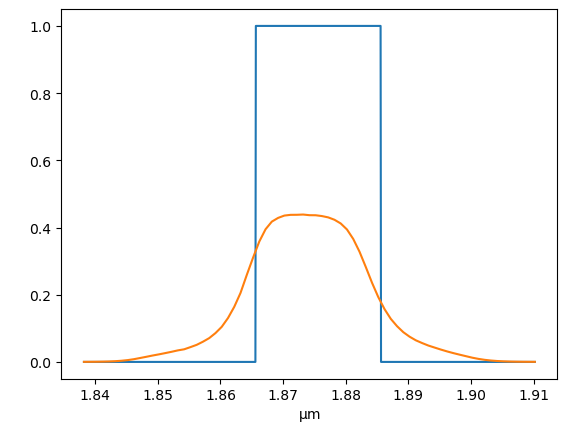

In [35]:
boxcen = paa
boxwd = 0.02*u.micron

def boxlambdam(boxcen, boxwid, plot=True):
    lamb1 = boxcen - boxwid/2
    lamb2 = boxcen + boxwid/2

    x = np.linspace(f187n['Wavelength'][0], f187n['Wavelength'][-1], 1024).to(u.um)
    dx = np.diff(x).mean()
    xtrans = np.interp(x, f187n['Wavelength'], f187n['Transmission'])
    
    boxspec = np.zeros_like(x) * u.erg/u.s * u.cm**-2 / u.micron
    boxspec[(x >= lamb1) & (x <= lamb2)] = 1*boxspec.unit

    numer = np.sum(boxspec * xtrans* x * dx)
    denom = np.sum(xtrans * x * dx)

    lm = (np.sum(boxspec*dx) / (numer/denom)) 

    if plot:
        plt.plot(x, boxspec.value)
        plt.plot(f187n['Wavelength'].to(paa.unit), f187n['Transmission'])

    return lm, lamb1, lamb2

def deltaspec_lambdam(cen):
    dl = np.diff(f187n['Wavelength']).mean()
    numer = np.sum(f187n['Transmission'] * f187n['Wavelength'] * dl)
    denom = cen*np.interp(cen.value, f187n['Wavelength'].to(cen.unit).value, f187n['Transmission'].value)
    return numer/denom

lm, l1, l2 = boxlambdam(paa, .02*u.micron)
lm.to(u.um), l2 - l1, deltaspec_lambdam(paa).to(paa.unit)

(<MaskedQuantity 0.04157812 um>,
 <Quantity 0.04 um>,
 <MaskedQuantity 0.02377922 um>)

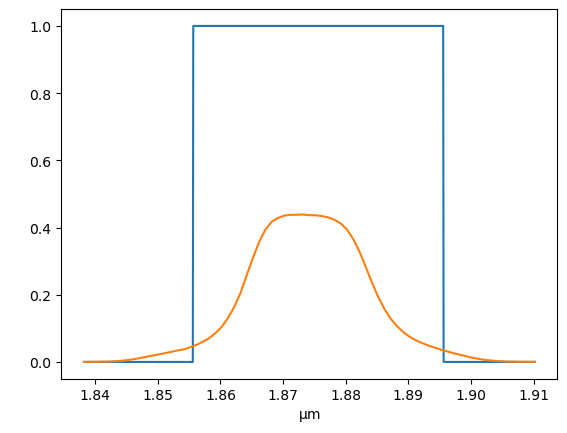

In [36]:

lm, l1, l2 = boxlambdam(paa, .04*u.micron)
lm.to(u.um), l2 - l1, deltaspec_lambdam(paa).to(paa.unit)

(<MaskedQuantity 0.02418324 um>,
 <Quantity 0.01 um>,
 <MaskedQuantity 0.02377922 um>)

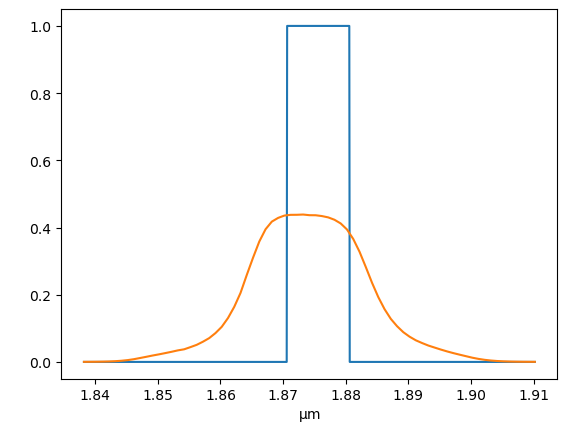

In [37]:
lm, l1, l2 = boxlambdam(paa, .01*u.micron)
lm.to(u.um), l2 - l1, deltaspec_lambdam(paa).to(paa.unit)

(<MaskedQuantity 0.02377881 um>,
 <Quantity 0.001 um>,
 <MaskedQuantity 0.02377922 um>)

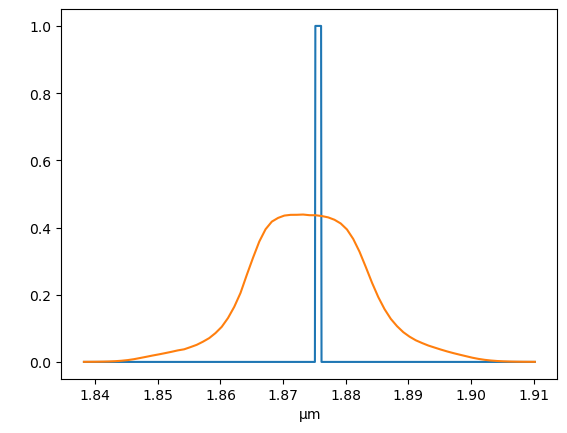

In [38]:
lm, l1, l2 = boxlambdam(paa, .001*u.micron)
lm.to(u.um), l2 - l1, deltaspec_lambdam(paa).to(paa.unit)

(<MaskedQuantity 0.05770546 um>,
 <Quantity 0.001 um>,
 <MaskedQuantity 0.05781114 um>)

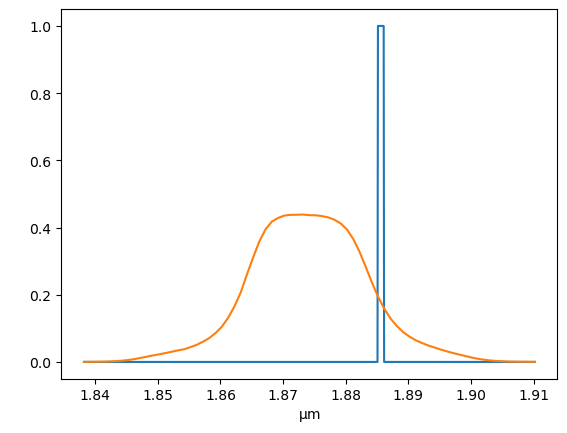

In [39]:
lm, l1, l2 = boxlambdam(paa+.01*u.um, .001*u.micron)
lm.to(u.um), l2 - l1, deltaspec_lambdam(paa+.01*u.um).to(paa.unit)

(<MaskedQuantity 0.03154295 um>,
 <Quantity 0.001 um>,
 <MaskedQuantity 0.03155889 um>)

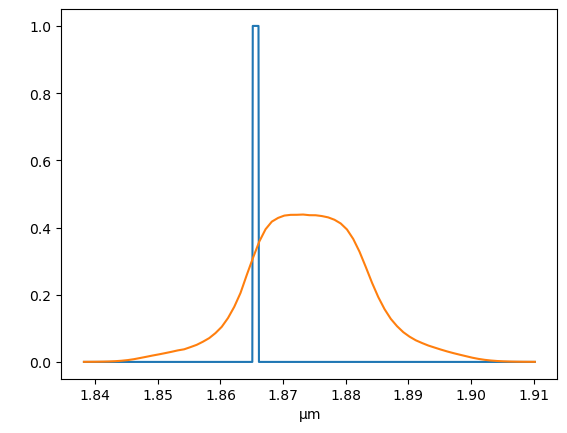

In [40]:
lm, l1, l2 = boxlambdam(paa-.01*u.um, .001*u.micron)
lm.to(u.um), l2 - l1, deltaspec_lambdam(paa-.01*u.um).to(paa.unit)

(<MaskedQuantity 0.03693312 um>,
 <Quantity 0.02 um>,
 <MaskedQuantity 0.03155889 um>)

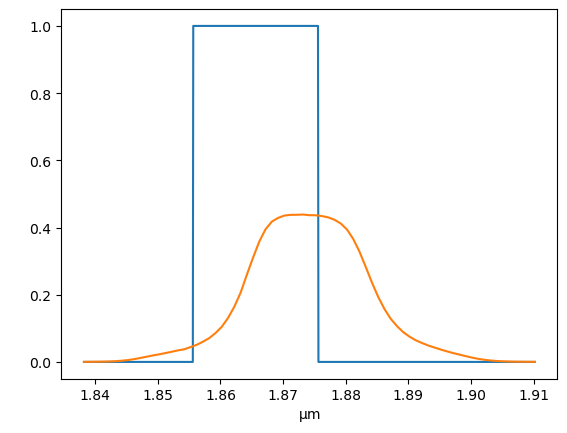

In [41]:
lm, l1, l2 = boxlambdam(paa-.01*u.um, .02*u.micron)
lm.to(u.um), l2 - l1, deltaspec_lambdam(paa-.01*u.um).to(paa.unit)